<a href="https://colab.research.google.com/github/Marland-Hamilton/Data-analysis-/blob/main/Customer_churn_WPyspark.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
! pip install pyspark

In [66]:
from pyspark.sql import SparkSession

import matplotlib.pyplot as plt
import plotly.express as px

import pandas as pd

from pyspark.sql.functions import col, when, count, udf
from pyspark.ml.feature import StringIndexer, Imputer
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

Build our spark session

In [51]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Customer_Churn_Prediction") \
    .getOrCreate()

spark

In [19]:
data = spark.read.format('csv').option('inferSchema',True).option('header', True).load('/dataset.csv')

In [21]:
data.show(4)

+----------+------+-------------+-------+----------+------+------------+----------------+---------------+--------------+------------+----------------+-----------+-----------+---------------+--------------+----------------+--------------------+--------------+------------+-----+
|customerID|gender|SeniorCitizen|Partner|Dependents|tenure|PhoneService|   MultipleLines|InternetService|OnlineSecurity|OnlineBackup|DeviceProtection|TechSupport|StreamingTV|StreamingMovies|      Contract|PaperlessBilling|       PaymentMethod|MonthlyCharges|TotalCharges|Churn|
+----------+------+-------------+-------+----------+------+------------+----------------+---------------+--------------+------------+----------------+-----------+-----------+---------------+--------------+----------------+--------------------+--------------+------------+-----+
|7590-VHVEG|Female|           No|    Yes|        No|     1|          No|No phone service|            DSL|            No|         Yes|              No|         No|    

In [23]:
data.head()

Row(customerID='7590-VHVEG', gender='Female', SeniorCitizen='No', Partner='Yes', Dependents='No', tenure=1, PhoneService='No', MultipleLines='No phone service', InternetService='DSL', OnlineSecurity='No', OnlineBackup='Yes', DeviceProtection='No', TechSupport='No', StreamingTV='No', StreamingMovies='No', Contract='Month-to-month', PaperlessBilling='Yes', PaymentMethod='Electronic check', MonthlyCharges=29.85, TotalCharges=29.85, Churn='No')

In [25]:
data.printSchema()

root
 |-- customerID: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- SeniorCitizen: string (nullable = true)
 |-- Partner: string (nullable = true)
 |-- Dependents: string (nullable = true)
 |-- tenure: integer (nullable = true)
 |-- PhoneService: string (nullable = true)
 |-- MultipleLines: string (nullable = true)
 |-- InternetService: string (nullable = true)
 |-- OnlineSecurity: string (nullable = true)
 |-- OnlineBackup: string (nullable = true)
 |-- DeviceProtection: string (nullable = true)
 |-- TechSupport: string (nullable = true)
 |-- StreamingTV: string (nullable = true)
 |-- StreamingMovies: string (nullable = true)
 |-- Contract: string (nullable = true)
 |-- PaperlessBilling: string (nullable = true)
 |-- PaymentMethod: string (nullable = true)
 |-- MonthlyCharges: double (nullable = true)
 |-- TotalCharges: double (nullable = true)
 |-- Churn: string (nullable = true)



In [26]:
data.count()

7043

In [28]:
data.columns

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [29]:
data.show(4)

+----------+------+-------------+-------+----------+------+------------+----------------+---------------+--------------+------------+----------------+-----------+-----------+---------------+--------------+----------------+--------------------+--------------+------------+-----+
|customerID|gender|SeniorCitizen|Partner|Dependents|tenure|PhoneService|   MultipleLines|InternetService|OnlineSecurity|OnlineBackup|DeviceProtection|TechSupport|StreamingTV|StreamingMovies|      Contract|PaperlessBilling|       PaymentMethod|MonthlyCharges|TotalCharges|Churn|
+----------+------+-------------+-------+----------+------+------------+----------------+---------------+--------------+------------+----------------+-----------+-----------+---------------+--------------+----------------+--------------------+--------------+------------+-----+
|7590-VHVEG|Female|           No|    Yes|        No|     1|          No|No phone service|            DSL|            No|         Yes|              No|         No|    

In [30]:
data.dtypes

[('customerID', 'string'),
 ('gender', 'string'),
 ('SeniorCitizen', 'string'),
 ('Partner', 'string'),
 ('Dependents', 'string'),
 ('tenure', 'int'),
 ('PhoneService', 'string'),
 ('MultipleLines', 'string'),
 ('InternetService', 'string'),
 ('OnlineSecurity', 'string'),
 ('OnlineBackup', 'string'),
 ('DeviceProtection', 'string'),
 ('TechSupport', 'string'),
 ('StreamingTV', 'string'),
 ('StreamingMovies', 'string'),
 ('Contract', 'string'),
 ('PaperlessBilling', 'string'),
 ('PaymentMethod', 'string'),
 ('MonthlyCharges', 'double'),
 ('TotalCharges', 'double'),
 ('Churn', 'string')]

In [34]:
numerical_columns

['tenure', 'MonthlyCharges', 'TotalCharges']

In [36]:
categorical_columns = [name for name, typ in data.dtypes if typ == 'string']
categorical_columns

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn']

In [37]:
data.select(numerical_columns).show()

+------+--------------+------------+
|tenure|MonthlyCharges|TotalCharges|
+------+--------------+------------+
|     1|         29.85|       29.85|
|    34|         56.95|      1889.5|
|     2|         53.85|      108.15|
|    45|          42.3|     1840.75|
|     2|          70.7|      151.65|
|     8|         99.65|       820.5|
|    22|          89.1|      1949.4|
|    10|         29.75|       301.9|
|    28|         104.8|     3046.05|
|    62|         56.15|     3487.95|
|    13|         49.95|      587.45|
|    16|         18.95|       326.8|
|    58|        100.35|      5681.1|
|    49|         103.7|      5036.3|
|    25|         105.5|     2686.05|
|    69|        113.25|     7895.15|
|    52|         20.65|     1022.95|
|    71|         106.7|     7382.25|
|    10|          55.2|      528.35|
|    21|         90.05|      1862.9|
+------+--------------+------------+
only showing top 20 rows


In [38]:
df = data.select(numerical_columns).toPandas()
df.head()

,tenure,MonthlyCharges,TotalCharges
0,1,29.85,29.85
1,34,56.95,1889.50
2,2,53.85,108.15
3,45,42.30,1840.75
4,2,70.70,151.65


/tmp/ipython-input-3846753046.py:3: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  df.hist(ax=ax, bins = 20)


,tenure
count,7043.000000
mean,32.435752
std,25.075228
min,0.000000
25%,9.000000
50%,29.000000
75%,55.000000
max,458.000000


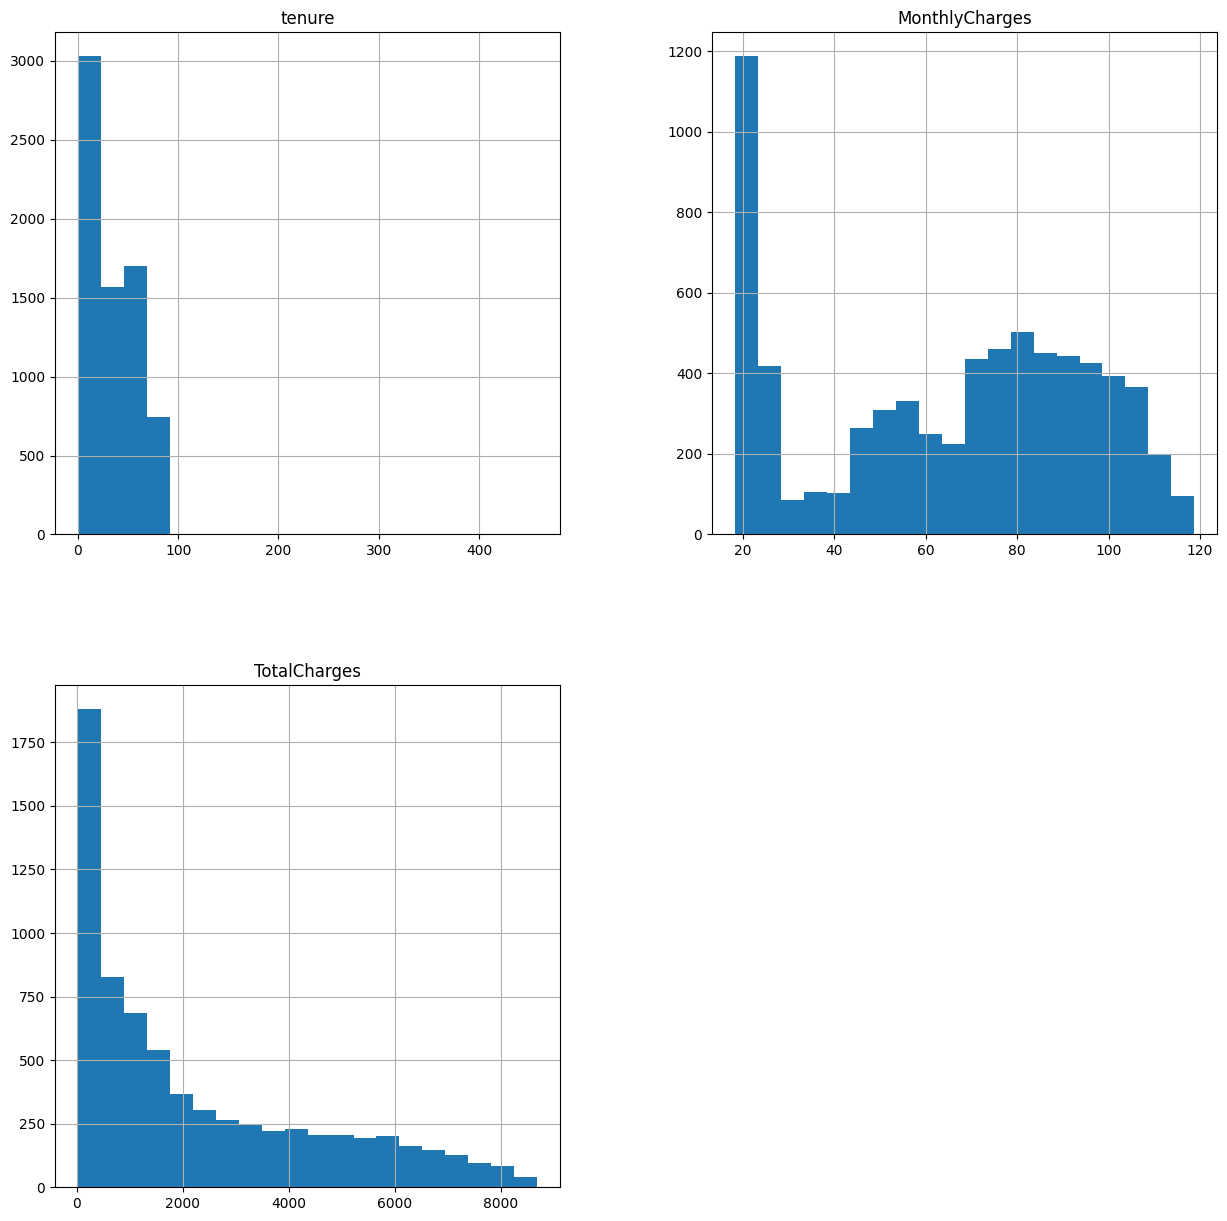

In [41]:
fig = plt.figure(figsize=(15,15))
ax = fig.gca()
df.hist(ax=ax, bins = 20)
df.tenure.describe()

Generate the Correlaton matrix

In [43]:
df.corr()

,tenure,MonthlyCharges,TotalCharges
tenure,1.000000,0.243703,0.806530
MonthlyCharges,0.243703,1.000000,0.651065
TotalCharges,0.806530,0.651065,1.000000


In [44]:
categorical_columns

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn']

In [45]:
data.select('contract').show()

+--------------+
|      contract|
+--------------+
|Month-to-month|
|      One year|
|Month-to-month|
|      One year|
|Month-to-month|
|Month-to-month|
|Month-to-month|
|Month-to-month|
|Month-to-month|
|      One year|
|Month-to-month|
|      Two year|
|      One year|
|Month-to-month|
|Month-to-month|
|      Two year|
|      One year|
|      Two year|
|Month-to-month|
|Month-to-month|
+--------------+
only showing top 20 rows


In [46]:
data.groupBy('contract').count().show()

+--------------+-----+
|      contract|count|
+--------------+-----+
|Month-to-month| 3875|
|      One year| 1473|
|      Two year| 1695|
+--------------+-----+



check the unique value count per each categorical variables

In [48]:
for column  in categorical_columns:
  data.groupBy(column).count().show()

+----------+-----+
|customerID|count|
+----------+-----+
|3668-QPYBK|    1|
|6234-RAAPL|    1|
|1894-IGFSG|    1|
|6982-SSHFK|    1|
|5859-HZYLF|    1|
|6479-OAUSD|    1|
|2592-YKDIF|    1|
|6718-BDGHG|    1|
|3195-TQDZX|    1|
|4248-QPAVC|    1|
|5668-MEISB|    1|
|5802-ADBRC|    1|
|2712-SYWAY|    1|
|2011-TRQYE|    1|
|7244-KXYZN|    1|
|0953-LGOVU|    1|
|3623-FQBOX|    1|
|3692-JHONH|    1|
|3528-HFRIQ|    1|
|7661-CPURM|    1|
+----------+-----+
only showing top 20 rows
+------+-----+
|gender|count|
+------+-----+
|Female| 3488|
|  Male| 3555|
+------+-----+

+-------------+-----+
|SeniorCitizen|count|
+-------------+-----+
|           No| 5901|
|          Yes| 1142|
+-------------+-----+

+-------+-----+
|Partner|count|
+-------+-----+
|     No| 3641|
|    Yes| 3402|
+-------+-----+

+----------+-----+
|Dependents|count|
+----------+-----+
|        No| 4933|
|       Yes| 2110|
+----------+-----+

+------------+-----+
|PhoneService|count|
+------------+-----+
|          No|  682|

Check for null values

In [53]:
data.select(col('Churn')).show()

+-----+
|Churn|
+-----+
|   No|
|   No|
|  Yes|
|   No|
|  Yes|
|  Yes|
|   No|
|   No|
|  Yes|
|   No|
|   No|
|   No|
|   No|
|  Yes|
|   No|
|   No|
|   No|
|   No|
|  Yes|
|   No|
+-----+
only showing top 20 rows


In [54]:
for columns in data.columns:
  print(columns, data.filter(col(columns).isNull()).count())

customerID 0
gender 0
SeniorCitizen 0
Partner 0
Dependents 0
tenure 0
PhoneService 0
MultipleLines 0
InternetService 0
OnlineSecurity 0
OnlineBackup 0
DeviceProtection 0
TechSupport 0
StreamingTV 0
StreamingMovies 0
Contract 0
PaperlessBilling 0
PaymentMethod 0
MonthlyCharges 0
TotalCharges 11
Churn 0


Removing Outliers

In [56]:
columns_with_missing_values = ['TotalCharges']

In [60]:
imputer = Imputer(
    inputCols=columns_with_missing_values, outputCols = columns_with_missing_values
).setStrategy('mean')

use Imputer to fill missing values

In [61]:
imputer = imputer.fit(data)
data = imputer.transform(data)

In [63]:
for columns in data.columns:
  print(columns, data.filter(col(columns).isNull()).count())

customerID 0
gender 0
SeniorCitizen 0
Partner 0
Dependents 0
tenure 0
PhoneService 0
MultipleLines 0
InternetService 0
OnlineSecurity 0
OnlineBackup 0
DeviceProtection 0
TechSupport 0
StreamingTV 0
StreamingMovies 0
Contract 0
PaperlessBilling 0
PaymentMethod 0
MonthlyCharges 0
TotalCharges 0
Churn 0


In [64]:
data.select('*').where(data.tenure > 100).show()

+----------+------+-------------+-------+----------+------+------------+-------------+---------------+--------------+------------+----------------+-----------+-----------+---------------+--------------+----------------+----------------+--------------+------------+-----+
|customerID|gender|SeniorCitizen|Partner|Dependents|tenure|PhoneService|MultipleLines|InternetService|OnlineSecurity|OnlineBackup|DeviceProtection|TechSupport|StreamingTV|StreamingMovies|      Contract|PaperlessBilling|   PaymentMethod|MonthlyCharges|TotalCharges|Churn|
+----------+------+-------------+-------+----------+------+------------+-------------+---------------+--------------+------------+----------------+-----------+-----------+---------------+--------------+----------------+----------------+--------------+------------+-----+
|5122-CYFXA|Female|           No|     No|        No|   458|         Yes|           No|            DSL|            No|         Yes|              No|        Yes|        Yes|            Yes|

In [65]:
print('before removing outlier', data.count())
data = data.filter(data.tenure < 100)
print('after removing outlier', data.count())

before removing outlier 7043
after removing outlier 7042


Feature Preperation

In [72]:
numerical_vector_assembler = VectorAssembler(inputCols=numerical_columns, outputCol='numerical_features_vector')

In [110]:
data = data.drop('numerical_features')


In [111]:
data = numerical_vector_assembler.transform(data)


IllegalArgumentException: Output column numerical_features_vector already exists.

In [115]:
data = data.drop('final_feature_vecture')

In [116]:
data.show()

+----------+------+-------------+-------+----------+------+------------+----------------+---------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+--------------+----------------+--------------------+--------------+------------+-----+-------------------------+-------------------------+------------------+--------------+---------------------+---------------+------------------+--------------------+---------------------+-----------------------+----------------------+--------------------+------------------------+-------------------+-------------------+-----------------------+----------------+------------------------+---------------------+-------------+---------------------------+--------------------+
|customerID|gender|SeniorCitizen|Partner|Dependents|tenure|PhoneService|   MultipleLines|InternetService|     OnlineSecurity|       OnlineBackup|   DeviceProtection|        TechSupport|        StreamingTV|    Streamin

SyntaxError: invalid syntax (ipython-input-3342767769.py, line 1)

In [117]:
scaler = StandardScaler(inputCol='numerical_features_vector', outputCol='numerical_features_scaled', withStd=True, withMean=True)

In [118]:
data = scaler.fit(data).transform(data)


IllegalArgumentException: requirement failed: Output column numerical_features_scaled already exists.

In [119]:
data.show()

+----------+------+-------------+-------+----------+------+------------+----------------+---------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+--------------+----------------+--------------------+--------------+------------+-----+-------------------------+-------------------------+------------------+--------------+---------------------+---------------+------------------+--------------------+---------------------+-----------------------+----------------------+--------------------+------------------------+-------------------+-------------------+-----------------------+----------------+------------------------+---------------------+-------------+---------------------------+--------------------+
|customerID|gender|SeniorCitizen|Partner|Dependents|tenure|PhoneService|   MultipleLines|InternetService|     OnlineSecurity|       OnlineBackup|   DeviceProtection|        TechSupport|        StreamingTV|    Streamin

Feature preperation - categorical features

In [120]:
# string indexing - we need to convert all strings columns to numeric
categorical_columns_indexed = [name + '_indexed' for name in categorical_columns]
indexer = StringIndexer(inputCols=categorical_columns, outputCols=categorical_columns_indexed)
data = indexer.fit(data).transform(data)

IllegalArgumentException: requirement failed: Output column customerID_indexed already exists.

In [121]:
data.show()

+----------+------+-------------+-------+----------+------+------------+----------------+---------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+--------------+----------------+--------------------+--------------+------------+-----+-------------------------+-------------------------+------------------+--------------+---------------------+---------------+------------------+--------------------+---------------------+-----------------------+----------------------+--------------------+------------------------+-------------------+-------------------+-----------------------+----------------+------------------------+---------------------+-------------+---------------------------+--------------------+
|customerID|gender|SeniorCitizen|Partner|Dependents|tenure|PhoneService|   MultipleLines|InternetService|     OnlineSecurity|       OnlineBackup|   DeviceProtection|        TechSupport|        StreamingTV|    Streamin

In [122]:
categorical_columns_indexed

['customerID_indexed',
 'gender_indexed',
 'SeniorCitizen_indexed',
 'Partner_indexed',
 'Dependents_indexed',
 'PhoneService_indexed',
 'MultipleLines_indexed',
 'InternetService_indexed',
 'OnlineSecurity_indexed',
 'OnlineBackup_indexed',
 'DeviceProtection_indexed',
 'TechSupport_indexed',
 'StreamingTV_indexed',
 'StreamingMovies_indexed',
 'Contract_indexed',
 'PaperlessBilling_indexed',
 'PaymentMethod_indexed',
 'Churn_indexed']

In [123]:

categorical_columns_indexed.remove('Churn_indexed')

In [124]:
categorical_columns_indexed

['customerID_indexed',
 'gender_indexed',
 'SeniorCitizen_indexed',
 'Partner_indexed',
 'Dependents_indexed',
 'PhoneService_indexed',
 'MultipleLines_indexed',
 'InternetService_indexed',
 'OnlineSecurity_indexed',
 'OnlineBackup_indexed',
 'DeviceProtection_indexed',
 'TechSupport_indexed',
 'StreamingTV_indexed',
 'StreamingMovies_indexed',
 'Contract_indexed',
 'PaperlessBilling_indexed',
 'PaymentMethod_indexed']

In [125]:

categorical_vector_assembler = VectorAssembler(inputCols=categorical_columns_indexed, outputCol='categorical_features_vector')
data = categorical_vector_assembler.transform(data)

data.show()

IllegalArgumentException: Output column categorical_features_vector already exists.

In [136]:
final_vector_assembler = VectorAssembler(inputCols=['numerical_features_scaled', 'categorical_features_vector'], outputCol='final_feature_vector')
data = final_vector_assembler.transform(data)

data.select('final_feature_vector','churn_indexed').show()

IllegalArgumentException: Output column final_feature_vector already exists.

Train model

In [137]:
train, test = data.randomSplit([0.7, 0.3], seed=100)

train.count()
test.count()

2112

In [138]:
train.show()

+----------+------+-------------+-------+----------+------+------------+----------------+---------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+--------------+----------------+--------------------+--------------+------------+-----+-------------------------+-------------------------+------------------+--------------+---------------------+---------------+------------------+--------------------+---------------------+-----------------------+----------------------+--------------------+------------------------+-------------------+-------------------+-----------------------+----------------+------------------------+---------------------+-------------+---------------------------+--------------------+
|customerID|gender|SeniorCitizen|Partner|Dependents|tenure|PhoneService|   MultipleLines|InternetService|     OnlineSecurity|       OnlineBackup|   DeviceProtection|        TechSupport|        StreamingTV|    Streamin

In [162]:
dt = DecisionTreeClassifier(featuresCol='final_feature_vector', labelCol='Churn_indexed', maxDepth= 6)

In [163]:
model = dt.fit(train)

In [164]:
predictions_test = model.transform(test)
predictions_test.select('Churn', 'prediction').show()

+-----+----------+
|Churn|prediction|
+-----+----------+
|  Yes|       1.0|
|   No|       0.0|
|   No|       0.0|
|   No|       0.0|
|   No|       0.0|
|  Yes|       1.0|
|   No|       0.0|
|  Yes|       0.0|
|   No|       0.0|
|   No|       0.0|
|   No|       0.0|
|   No|       0.0|
|   No|       0.0|
|  Yes|       0.0|
|   No|       0.0|
|   No|       1.0|
|   No|       0.0|
|   No|       0.0|
|   No|       0.0|
|   No|       0.0|
+-----+----------+
only showing top 20 rows


evaluate the data

In [165]:
Evaluator = BinaryClassificationEvaluator(labelCol='Churn_indexed')
auc_test = Evaluator.evaluate(predictions_test,{Evaluator.metricName: 'areaUnderROC'})
auc_test

0.7968193482241807

In [166]:
predictions_train = model.transform(train)
auc_train = Evaluator.evaluate(predictions_train,{Evaluator.metricName: 'areaUnderROC'})
auc_train

0.7976224624061719

Hyper parameter tuning


In [155]:
def evaluate_dt(mode_params):
      test_accuracies = []
      train_accuracies = []

      for maxD in mode_params:
        # train the model based on the maxD
        decision_tree = DecisionTreeClassifier(featuresCol = 'final_feature_vector', labelCol = 'Churn_indexed', maxDepth = maxD)
        dtModel = decision_tree.fit(train)

        # calculating test error
        predictions_test = dtModel.transform(test)
        evaluator = BinaryClassificationEvaluator(labelCol="Churn_indexed")
        auc_test = evaluator.evaluate(predictions_test, {evaluator.metricName: "areaUnderROC"})
        # recording the accuracy
        test_accuracies.append(auc_test)

        # calculating training error
        predictions_training = dtModel.transform(train)
        evaluator = BinaryClassificationEvaluator(labelCol="Churn_indexed")
        auc_training = evaluator.evaluate(predictions_training, {evaluator.metricName: "areaUnderROC"})
        train_accuracies.append(auc_training)

      return(test_accuracies, train_accuracies)

In [157]:
maxDepths = [2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20]
test_accuracies, train_accuracies = evaluate_dt(maxDepths)
print(test_accuracies)
print(train_accuracies)

In [158]:
df2 = pd.DataFrame()
df2['maxDepth'] = maxDepths
df2['test_accuracies'] = test_accuracies
df2['train_accuracies'] = train_accuracies

df2

,maxDepth,test_accuracies,train_accuracies
0,2,0.791874,0.773771
1,3,0.767823,0.772111
2,4,0.693851,0.673202
3,5,0.566494,0.564740
4,6,0.796819,0.797622
5,7,0.745993,0.760092
6,8,0.748844,0.761281
7,9,0.738666,0.785827
8,10,0.757609,0.826359
9,11,0.771064,0.863110


In [161]:
px.line(df2, x='maxDepth', y=['test_accuracies', 'train_accuracies'])

Deploying the model

In [170]:
feature_importance = model.featureImportances
scores = [score for i, score in enumerate(feature_importance)]
scores

[np.float64(0.20753761020590825),
 np.float64(0.01385123867305721),
 np.float64(0.005029446032347224),
 np.float64(0.0012458380271707754),
 np.float64(0.005061505966322666),
 np.float64(0.0),
 np.float64(0.005199436353121311),
 np.float64(0.01366052515814035),
 np.float64(0.01886958920289686),
 np.float64(0.1456573085640415),
 np.float64(0.03365494880670868),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0025086634426406532),
 np.float64(0.011532687359842643),
 np.float64(0.010285800594289672),
 np.float64(0.5047521232804218),
 np.float64(0.0025706057498663584),
 np.float64(0.01858267258322399)]

In [181]:
df3 = [col for col in categorical_columns_indexed if col != 'customerID_indexed'] + numerical_columns
df3 = pd.DataFrame(scores, columns= ['score'], index= index_for_df3)

In [182]:
px.bar(df3, y='score')